Vegetation Change in Aerial photographs of Urban Sprawl and foresty areas



In [26]:
%matplotlib inline

import cv2
import numpy as np 
from matplotlib import pyplot as plt 
from matplotlib import image as image
from pathlib import Path

In [27]:
#images are read from (parent)\Images, results go to (parent)\pairs
SRC_DIR = Path("..") / "Images"
OUT_DIR = Path("..") / "pairs"


#each item in folder looped through only looking for jpeg,jpg,png collecting file paths in a list. anything else is ignored. 
#turns them into lowercase and sorts them by name.
source_images = sorted(
    (p for p in SRC_DIR.iterdir() if p.suffix.lower() in {".jpeg", ".jpg", ".png"}),
    key=lambda p: p.name.casefold(),
)
print(f"Found {len(source_images)} images")#print how many images found

Found 10 images


In [28]:
def find_divider(img, split_columns):
    #returns (start,end): the pixel range to remove between the two panels/images.
    #for a left/right image we work with columns.For a top/bottom image we
    #transpose it so rows become columns and the same code works for both.
    work = img if split_columns else img.transpose(1, 0, 2)
    h, w = work.shape[:2]
    #avoid other edges and divider is always near middle, search the middle 20% of the image (40% to 60% across)
    lo, hi = int(w * 0.4), int(w * 0.6)

    #looking at sample images, either there is a white gap between the panels, or there no gap and the average colour is different.We try both methods.
    #case 1: a white gap between the panels
    gray = cv2.cvtColor(work, cv2.COLOR_BGR2GRAY)
    white = (gray > 240).mean(axis=0) > 0.9 #true for columns that are >90% white
    cols = np.where(white[lo:hi])[0] + lo # positions of those white columns
    
    #if no white columns found, we will use the other method below
    if len(cols) > 0:
    #group neighbouring white columns into streak/run and take the longest streak
        runs = np.split(cols, np.where(np.diff(cols) > 1)[0] + 1)
        run = max(runs, key=len)
        return int(run[0]), int(run[-1]) + 1#start and end of the gap

    #case 2: no white gap, but the average colour is different on each side of the divider
    blur = cv2.GaussianBlur(work, (5, 5), 0)#smooth out images so less confusion
    
    best_x = w // 2 #fall back to the middle and consider best cut position
    best_score = 0 #how different the two sides are, higher is better
    for x in range(int(w * 0.46), int(w * 0.54)): #no gap means roughly a 50/50 split, so search an even narrower band (46% to 54%)
        left = blur[:, x - 8:x].mean(axis=1) # average colour of the 8 columns on the left, per row
        right = blur[:, x:x + 8].mean(axis=1) # average colour of the 8 columns on the right, per row
        difference = np.abs(right - left).sum(axis=1) #how different they are, per row
        score = np.median(difference)# typical difference down the whole height
        if score > best_score:
            best_score = score
            best_x = x

    return best_x, best_x

In [29]:
def split_image(source_path, pair_number):
    output_dir = OUT_DIR / f"{pair_number:02d}"
    output_dir.mkdir(parents=True, exist_ok=True)

    full_image = cv2.imread(str(source_path), cv2.IMREAD_COLOR)
    if full_image is None:
        raise ValueError(f"Could not read image: {source_path}")

    height, width = full_image.shape[:2]
    split_columns = width >= height

    start, end = find_divider(full_image, split_columns)

    if split_columns:
        before, after = full_image[:, :start], full_image[:, end:]
        orientation = "left/right"
    else:
        before, after = full_image[:start, :], full_image[end:, :]
        orientation = "top/bottom"

    for name, img in (("before", before), ("after", after)):
        if not cv2.imwrite(str(output_dir / f"{name}.png"), img):
            raise OSError(f"Could not write image: {output_dir / name}.png")

    return orientation, (start, end), before, after

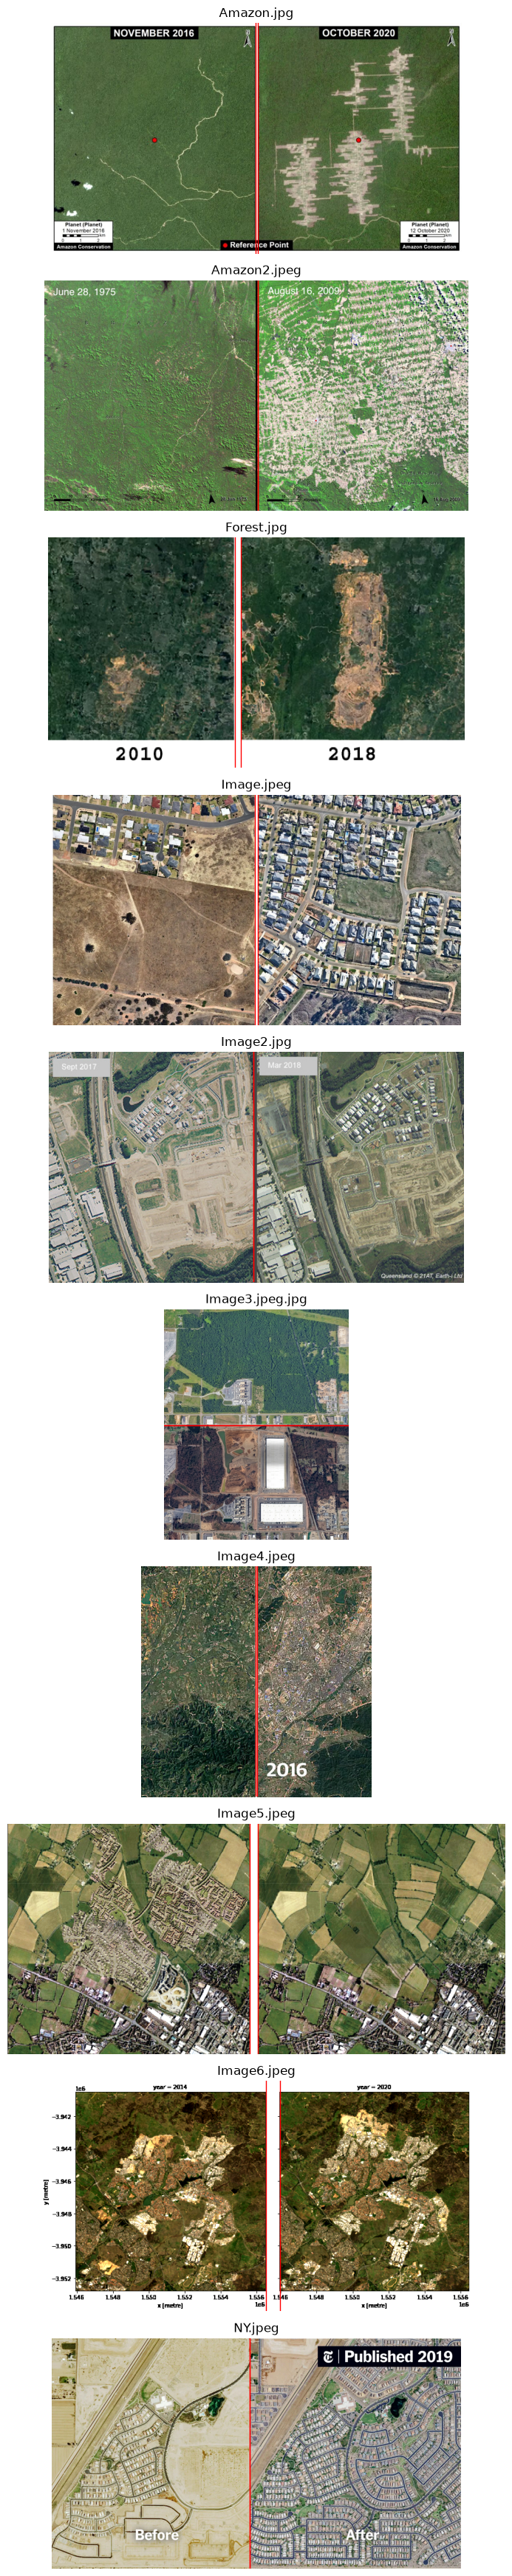

In [30]:
fig, axes = plt.subplots(len(source_images), 1, figsize=(12, 3.5 * len(source_images)))
axes = np.atleast_1d(axes)

for ax, path in zip(axes, source_images):
    img = cv2.imread(str(path))
    split_columns = img.shape[1] >= img.shape[0]
    start, end = find_divider(img, split_columns)

    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    line = ax.axvline if split_columns else ax.axhline
    line(start, color="red", lw=1)
    line(end, color="red", lw=1)
    ax.set_title(path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
for pair_number, source_path in enumerate(source_images, start=1):
    orientation, (start, end), before, after = split_image(source_path, pair_number)
    print(f"{pair_number:02d} {source_path.name}: {orientation}, cut at {start}-{end}, "
        f"before={before.shape[1]}x{before.shape[0]}, after={after.shape[1]}x{after.shape[0]}")

01 Amazon.jpg: left/right, cut at 510-515, before=510x574, after=509x574
02 Amazon2.jpeg: left/right, cut at 604-604, before=604x653, after=596x653
03 Forest.jpg: left/right, cut at 234-242, before=234x289, after=281x289
04 Image.jpeg: left/right, cut at 953-967, before=953x1080, after=953x1080
05 Image2.jpg: left/right, cut at 354-354, before=354x400, after=366x400
06 Image3.jpeg.jpg: top/bottom, cut at 578-578, before=922x578, after=922x574
07 Image4.jpeg: left/right, cut at 596-603, before=596x1200, after=597x1200
08 Image5.jpeg: left/right, cut at 456-471, before=456x434, after=466x434
09 Image6.jpeg: left/right, cut at 415-440, before=415x424, after=355x424
10 NY.jpeg: left/right, cut at 775-775, before=775x901, after=825x901
